# Super Store assigment
  Lazar Vidić
---



First step in this project is to import the necessary libraries. We are importing libraries for data transformations and data visualisation.
Next step is to read the CSV files from GitHub.

In [618]:
#Data operations library
import pandas as pd
#Math and statistical operations library
import numpy as np
#Data visualisations libraries
import matplotlib.pyplot as plt
import seaborn as sns   
import scipy.stats as stats

#Read CSV files
df_orders = pd.read_csv("data/super_store_us.xlsx - Orders .csv")
df_returns = pd.read_csv("data/super_store_us.xlsx - Returns.csv")
df_users = pd.read_csv("data/super_store_us.xlsx - Users.csv")


We need to load the Super Store dataset, which contains information about prices, categories, shipments and etc.

What format is the dataset ? What is represented in the rows, and what is represented in the columns? How many samples are there, and how many features?

To answer these and similar questions, we will use `shape` and `dtypes`.

Presentation of a small parts of our data, in order to see what we are working with. 

In [619]:
print("Orders:")
print(df_orders.head(10))

Orders:
   Row ID Order Priority  Discount  Unit Price  Shipping Cost  Customer ID  \
0   20847           High      0.01        2.84           0.93            3   
1   20228  Not Specified      0.02      500.98          26.00            5   
2   21776       Critical      0.06        9.48           7.29           11   
3   24844         Medium      0.09       78.69          19.99           14   
4   24846         Medium      0.08        3.28           2.31           14   
5   24847         Medium      0.05        3.28           4.20           14   
6   24848         Medium      0.05        3.58           1.63           14   
7   18181       Critical      0.00        4.42           4.99           15   
8   20925         Medium      0.01       35.94           6.66           15   
9   26267           High      0.04        2.98           1.58           16   

       Customer Name       Ship Mode Customer Segment Product Category  ...  \
0      Bonnie Potter     Express Air        Corporate 

In [620]:
df_orders.shape

(1952, 25)

In [621]:
print("Returns:")
print(df_returns.head(5))

Returns:
   Order ID    Status
0        65  Returned
1       612  Returned
2       614  Returned
3       678  Returned
4       710  Returned


In [622]:
df_returns.shape

(1634, 2)

In [623]:
print("Users:")
print(df_users.head(5))

Users:
    Region  Manager
0  Central    Chris
1     East     Erin
2    South      Sam
3     West  William


In [624]:
df_users.shape

(4, 2)

Next step, we need to calculate the basic statistical measures for each feature using the `describe` function.


In [625]:
df_orders.drop(columns=['Row ID', 'Customer ID' , 'Order ID']).describe()

,Discount,Unit Price,Shipping Cost,Product Base Margin,Postal Code,Profit,Quantity ordered new,Sales
count,1952.000000,1952.000000,1952.000000,1936.000000,1952.000000,1952.000000,1952.000000,1952.000000
mean,0.048975,109.079221,12.968151,0.515186,51534.769467,114.793859,12.944672,985.828832
std,0.031378,393.481301,17.414631,0.137055,29362.828420,1141.112387,13.871565,2559.900167
min,0.000000,1.140000,0.490000,0.350000,1001.000000,-16476.838000,1.000000,2.250000
25%,0.020000,6.480000,3.230000,0.380000,28560.000000,-84.485400,5.000000,58.807500
50%,0.050000,20.990000,6.150000,0.525000,48765.500000,1.476450,10.000000,202.395000
75%,0.080000,100.972500,14.362500,0.590000,78550.000000,116.201575,16.000000,802.945000
max,0.210000,6783.020000,164.730000,0.850000,99362.000000,9228.225600,167.000000,45737.330000


In this table we see some mismatches in numbers of colums, "Product Base Margin" has less rows than other features. Also we notice realy big differences in "Profit" ans "Sales" columns. In next steps we need to figure out how to fix this problems.

In this step we will use `info` function to see data types in our data, and also if there are any null values.

In [626]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1952 entries, 0 to 1951
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Row ID                1952 non-null   int64  
 1   Order Priority        1952 non-null   object 
 2   Discount              1952 non-null   float64
 3   Unit Price            1952 non-null   float64
 4   Shipping Cost         1952 non-null   float64
 5   Customer ID           1952 non-null   int64  
 6   Customer Name         1952 non-null   object 
 7   Ship Mode             1952 non-null   object 
 8   Customer Segment      1952 non-null   object 
 9   Product Category      1952 non-null   object 
 10  Product Sub-Category  1952 non-null   object 
 11  Product Container     1952 non-null   object 
 12  Product Name          1952 non-null   object 
 13  Product Base Margin   1936 non-null   float64
 14  Country               1952 non-null   object 
 15  Region               

First step in our data transformations is replacing values in the "Order Priority" column for easier presentation of the data. We are replacing "Not Specificed" priority with "None".

In [627]:
df_orders["Order Priority"] = df_orders["Order Priority"].replace("Not Specified","None")


print(df_orders["Order Priority"].value_counts(dropna=False))

Low          398
None         396
High         391
Critical     390
Medium       376
Critical       1
Name: Order Priority, dtype: int64


In the table above, we can see how many different values the column has and how many times each of these values appears in the column.

The next step is transforming the Discount column. We want to rename the column to make its meaning clearer. Instead of keeping the generic name "Discount", we give it a more descriptive name, such as "Discount in %", so that it explicitly indicates that the values represent percentages. This improves the readability of the dataset and makes it easier to understand in later analysis.

The second part of this transformation is to convert the values into percentages. In the original dataset, the discount values are usually stored as decimal fractions (for example, 0.2 represents 20%). To make the column more intuitive, we multiply all values by 100, so that the number directly corresponds to a percentage. After this operation, we can also round the numbers to whole integers to simplify interpretation.

In [628]:
#Change the name of column 
df_orders.rename(columns={"Discount": "Discount in %"}, inplace=True)

#Transform in percentage
df_orders["Discount in %"] = (df_orders["Discount in %"] * 100).round(0).astype(int)

Check the result of the "Discount in %" column transformation.

In [629]:
df_orders.head(10)

,Row ID,Order Priority,Discount in %,Unit Price,Shipping Cost,Customer ID,Customer Name,Ship Mode,Customer Segment,Product Category,...,Region,State or Province,City,Postal Code,Order Date,Ship Date,Profit,Quantity ordered new,Sales,Order ID
0,20847,High,1,2.84,0.93,3,Bonnie Potter,Express Air,Corporate,Office Supplies,...,West,Washington,Anacortes,98221,1/7/2015,1/8/2015,4.5600,4,13.01,88522
1,20228,None,2,500.98,26.00,5,Ronnie Proctor,Delivery Truck,Home Office,Furniture,...,West,California,San Gabriel,91776,6/13/2015,6/15/2015,4390.3665,12,6362.85,90193
2,21776,Critical,6,9.48,7.29,11,Marcus Dunlap,Regular Air,Home Office,Furniture,...,East,New Jersey,Roselle,7203,2/15/2015,2/17/2015,-53.8096,22,211.15,90192
3,24844,Medium,9,78.69,19.99,14,Gwendolyn F Tyson,Regular Air,Small Business,Furniture,...,Central,Minnesota,Prior Lake,55372,5/12/2015,5/14/2015,803.4705,16,1164.45,86838
4,24846,Medium,8,3.28,2.31,14,Gwendolyn F Tyson,Regular Air,Small Business,Office Supplies,...,Central,Minnesota,Prior Lake,55372,5/12/2015,5/13/2015,-24.0300,7,22.23,86838
5,24847,Medium,5,3.28,4.20,14,Gwendolyn F Tyson,Regular Air,Small Business,Office Supplies,...,Central,Minnesota,Prior Lake,55372,5/12/2015,5/13/2015,-37.0300,4,13.99,86838
6,24848,Medium,5,3.58,1.63,14,Gwendolyn F Tyson,Regular Air,Small Business,Office Supplies,...,Central,Minnesota,Prior Lake,55372,5/12/2015,5/13/2015,-0.7100,4,14.26,86838
7,18181,Critical,0,4.42,4.99,15,Timothy Reese,Regular Air,Small Business,Office Supplies,...,East,New York,Smithtown,11787,4/8/2015,4/9/2015,-59.8200,7,33.47,86837
8,20925,Medium,1,35.94,6.66,15,Timothy Reese,Regular Air,Small Business,Office Supplies,...,East,New York,Smithtown,11787,5/28/2015,5/28/2015,261.8757,10,379.53,86839
9,26267,High,4,2.98,1.58,16,Sarah Ramsey,Regular Air,Small Business,Office Supplies,...,East,New York,Syracuse,13210,2/12/2015,2/15/2015,2.6300,6,18.80,86836


In columns "Unit Price" and "Shipping Cost" we will round all the numbers to 2 decimal places, in order for them to be all the same and more readable.

In [630]:
df_orders["Unit Price"] = df_orders["Unit Price"].round(2)

df_orders["Shipping Cost"] = df_orders["Shipping Cost"].round(2)

Check the result in columns "Unit Price" and "Shipping Cost".

In [631]:
df_orders[["Unit Price", "Shipping Cost"]].head(10)

,Unit Price,Shipping Cost
0,2.84,0.93
1,500.98,26.00
2,9.48,7.29
3,78.69,19.99
4,3.28,2.31
5,3.28,4.20
6,3.58,1.63
7,4.42,4.99
8,35.94,6.66
9,2.98,1.58


In previos text I described a problem with the column "Product Base Margin". In this column we have 16 empty cells and they are all for the same few products, so we can't find product base margin for them. The easiest way to solve this problem is to delete rows with empty strings in column "Product Base Margin", since the number of the empty cells is very small compared to the whole dataset.

In [632]:
#Show products that dont have Product Base Margin information
products_with_no_margin = df_orders.loc[df_orders['Product Base Margin'].isna(), 'Product Name'].unique()
print(products_with_no_margin)

['SAFCO Arco Folding Chair' 'SAFCO Folding Chair Trolley'
 'SAFCO PlanMaster Heigh-Adjustable Drafting Table Base, 43w x 30d x 30-37h, Black'
 'Safco Contoured Stacking Chairs' 'Safco Industrial Wire Shelving'
 'SAFCO Commercial Wire Shelving, Black']


In [633]:
#There aren't any other rows for these products from where we could get the Base Margin information
for product in products_with_no_margin:
    margin = df_orders[(df_orders['Product Name'] == product) & df_orders['Product Base Margin'].notna()].shape[0] > 0
    status = "Has not NaN values" if margin else "All values are NaN"
    print(f"{product} -> {status} \n")

SAFCO Arco Folding Chair -> All values are NaN 

SAFCO Folding Chair Trolley -> All values are NaN 

SAFCO PlanMaster Heigh-Adjustable Drafting Table Base, 43w x 30d x 30-37h, Black -> All values are NaN 

Safco Contoured Stacking Chairs -> All values are NaN 

Safco Industrial Wire Shelving -> All values are NaN 

SAFCO Commercial Wire Shelving, Black -> All values are NaN 



In [634]:
df_orders = df_orders.dropna(subset=["Product Base Margin"])

Check the result. Now we have 1936 rows of data available that have information in all of the columns.

In [635]:
df_orders.describe()

,Row ID,Discount in %,Unit Price,Shipping Cost,Customer ID,Product Base Margin,Postal Code,Profit,Quantity ordered new,Sales,Order ID
count,1936.000000,1936.000000,1936.000000,1936.000000,1936.000000,1936.000000,1936.000000,1936.000000,1936.000000,1936.000000,1936.000000
mean,19917.548554,4.885847,108.034685,12.783280,1733.831095,0.515186,51545.004132,111.065806,12.965909,971.861968,82347.225207
std,5968.385953,3.134024,394.836173,17.289631,990.512340,0.137055,29351.770516,1136.352380,13.913943,2559.347078,19075.071929
min,64.000000,0.000000,1.140000,0.490000,3.000000,0.350000,1001.000000,-16476.838000,1.000000,2.250000,359.000000
25%,19121.000000,2.000000,6.480000,3.032500,874.000000,0.380000,28560.000000,-83.675000,5.000000,58.515000,86783.750000
50%,21167.500000,5.000000,20.990000,6.095000,1738.000000,0.525000,48823.000000,1.300200,10.000000,200.660000,88376.000000
75%,23499.750000,7.000000,99.230000,14.000000,2578.000000,0.590000,78550.000000,113.473725,16.000000,774.920000,89961.000000
max,26389.000000,21.000000,6783.020000,164.730000,3403.000000,0.850000,99362.000000,9228.225600,167.000000,45737.330000,91586.000000


In column "Profit" and "Sales" we will round all the numbers to 2 decimal places, in order for them to be all the same and more readable.

In [636]:
df_orders["Profit"] = df_orders["Profit"].round(2)

df_orders["Sales"] = df_orders["Sales"].round(2)

Check the result in columns "Region", "Profit" and "Sales".

In [637]:
df_orders[["Region", "Profit", "Sales"]].head(10)

,Region,Profit,Sales
0,West,4.56,13.01
1,West,4390.37,6362.85
2,East,-53.81,211.15
3,Central,803.47,1164.45
4,Central,-24.03,22.23
5,Central,-37.03,13.99
6,Central,-0.71,14.26
7,East,-59.82,33.47
8,East,261.88,379.53
9,East,2.63,18.80


We have three CSV files, which represent three separate datasets. These datasets can be merged using the common ID columns to combine the information into a single dataset.

We will use `merge` function to merge orders with returns to see which orders are "Refound" and which orders are not "Refound", we will merge datasets on common column "Order ID". Also we will merge dataset orders with dataset users on common column "Region" to see who is a "Manager" in each "Region."

We are using a left join because we want to keep all the values from the "Order ID" column and add the corresponding "Status" information from the other dataset. After the join, the "Status" column contains both "Returned" values and NaN's. These NaN values indicate orders that were not returned, so we can replace them with "Delivered" in the next steps to complete the dataset.

In [638]:
#merge dataset orders and dataset returns on "Order ID"
df = pd.merge(df_orders, df_returns, on="Order ID", how="left")

We are using an inner join because we want to match the values in the "Region" column with the corresponding "Region" information in the other dataset. As a result, we now have a complete list of managers for each region, allowing us to see which manager is responsible for which region.

In [639]:
#merge dataset orders and dataset users on "Region"
df1 = pd.merge(df_orders, df_users, on="Region", how="inner")

Check the result of merging orders and users, shown through columns "Profit" and "Manager".

In [640]:
df1[["Profit", "Manager"]].head(10)

,Profit,Manager
0,4.56,William
1,4390.37,William
2,314.48,William
3,-114.64,William
4,-28.30,William
5,-5.31,William
6,8.89,William
7,144.69,William
8,-35.88,William
9,210.00,William


We will group profit by the managers, and result is shown down bellow.

In [641]:
#groupby function
profit_per_manager = df1.groupby("Manager")["Profit"].sum()

print(profit_per_manager)

Manager
Chris      78645.85
Erin       85577.43
Sam       -17431.38
William    68231.58
Name: Profit, dtype: float64


Check the result of merging orders and returns, shown through columns "Status" and "Customer Name".

In [642]:
df[["Status", "Customer Name"]].head(10)

,Status,Customer Name
0,NaN,Bonnie Potter
1,NaN,Ronnie Proctor
2,NaN,Marcus Dunlap
3,NaN,Gwendolyn F Tyson
4,NaN,Gwendolyn F Tyson
5,NaN,Gwendolyn F Tyson
6,NaN,Gwendolyn F Tyson
7,NaN,Timothy Reese
8,NaN,Timothy Reese
9,NaN,Sarah Ramsey


In this step we will check our dates. If our dates is in past we can say that is already delivered pacage or returened. Alse we can replace NaN values with "Delivered".

In [643]:
latest_date = df_orders["Ship Date"].max()
print("The latest delivery date is:", latest_date)

The latest delivery date is: 7/8/2015


In the table above we see NaN values in column "Status". We will fill empty(NaN) cells in column "Status" with "Delivered". Now we have "Refound" and "Delivered" orders in "Status" column. 

In [644]:
df["Status"].value_counts()

Returned    15
Name: Status, dtype: int64

In [645]:
num_of_nan = df['Status'].isna().sum()
print(f"Num of NaN values for 'Status' is {num_of_nan}, which is {(num_of_nan/len(df['Status'])).round(2)}% of all the values.")

Num of NaN values for 'Status' is 1921, which is 0.99% of all the values.


In [646]:
df["Status"] = df["Status"].fillna("Delivered")


Check the result of filling the empty cells through columns "Status" and "Customer Name".

In [647]:
df[["Status", "Customer Name"]].head(10)

,Status,Customer Name
0,Delivered,Bonnie Potter
1,Delivered,Ronnie Proctor
2,Delivered,Marcus Dunlap
3,Delivered,Gwendolyn F Tyson
4,Delivered,Gwendolyn F Tyson
5,Delivered,Gwendolyn F Tyson
6,Delivered,Gwendolyn F Tyson
7,Delivered,Timothy Reese
8,Delivered,Timothy Reese
9,Delivered,Sarah Ramsey


In this part of the notebook, we will show some graphics to represent our data.

This graphic represents simply different values of "Status", there is count of "Delivered" and count of "Returned" orders.

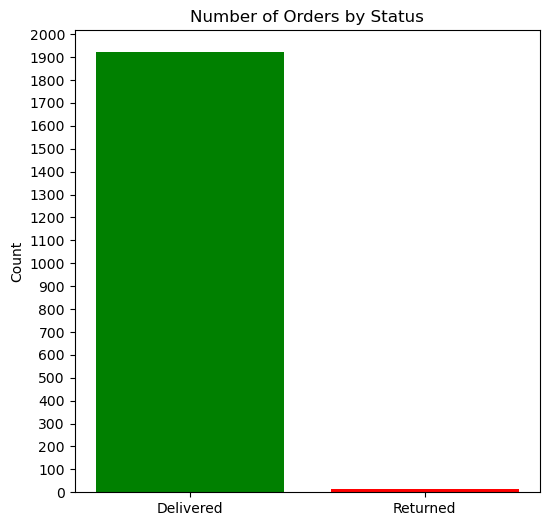

In [648]:
status_counts = df["Status"].value_counts()

plt.figure(figsize=(6,6))
plt.bar(status_counts.index, status_counts.values, color=["green", "red"])

plt.title("Number of Orders by Status")
plt.ylabel("Count")

max_count = status_counts.max()
plt.yticks(range(0, max_count + 100, 100))  

plt.show()

This graphic represents simply different values of "Status", there is count of "Delivered" and count of "Returned" orders but in percentage.

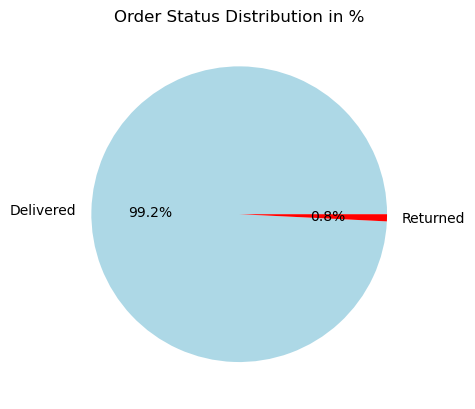

In [649]:
df["Status"].value_counts().plot(kind="pie", autopct='%1.1f%%', colors=["lightblue","red"])
plt.title("Order Status Distribution in %")
plt.ylabel("")  
plt.show()


This graphic represents 10 customers with the most orders.

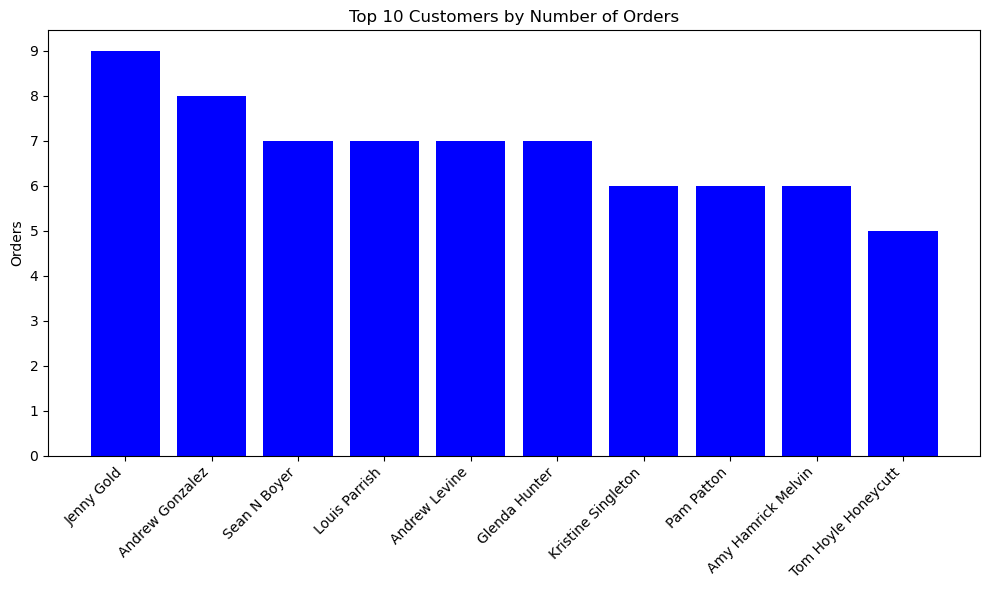

In [650]:
top_customers = df["Customer Name"].value_counts().head(10)

plt.figure(figsize=(10,6))
bars = plt.bar(top_customers.index, top_customers.values, color="blue")

plt.title("Top 10 Customers by Number of Orders")
plt.ylabel("Orders")


max_count = top_customers.max()
step = 1 
plt.yticks(range(0, max_count + step, step))


plt.xticks(rotation=45, ha="right") 
plt.tight_layout()
plt.show()


This graphic compares total sales and total profit and presents the numbers of both.

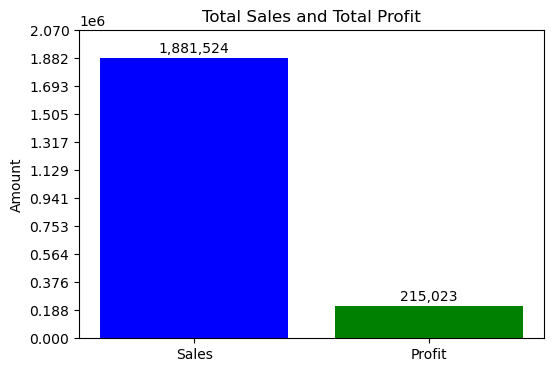

In [651]:
totals = df[["Sales", "Profit"]].sum()

plt.figure(figsize=(6,4))
bars = plt.bar(totals.index, totals.values, color=["blue", "green"])

plt.title("Total Sales and Total Profit")
plt.ylabel("Amount")

max_val = totals.max()
step = max_val // 10 
plt.yticks(range(0, int(max_val + step), int(step)))

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max_val*0.01, f"{int(height):,}",
             ha='center', va='bottom')

plt.show()


This graphic represents total "Profit" by "Region".

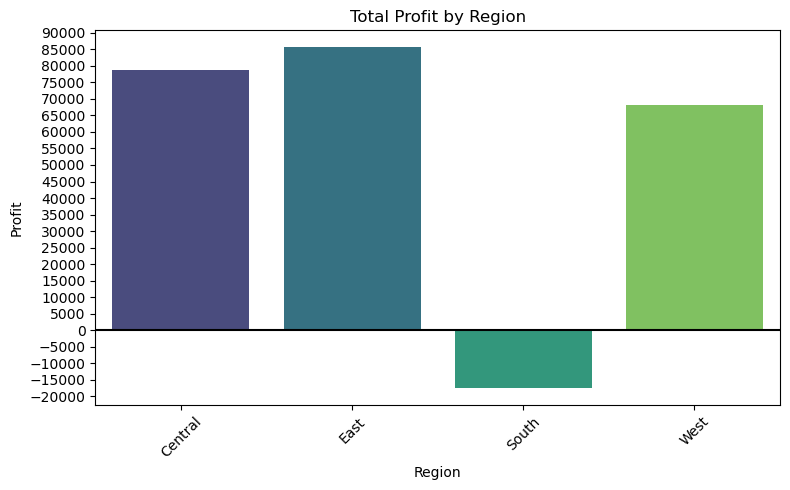

In [652]:
grouped = df1.groupby("Region")["Profit"].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x="Region", y="Profit", data=grouped, palette="viridis")

plt.axhline(0, color="black")
plt.title("Total Profit by Region")
plt.xticks(rotation=45)

max_profit = grouped["Profit"].max()
plt.yticks(range(-20000, int(max_profit + 5000), 5000))

plt.tight_layout()
plt.show()


This graphic shows top 5 purchases in our data and what is bought in them.

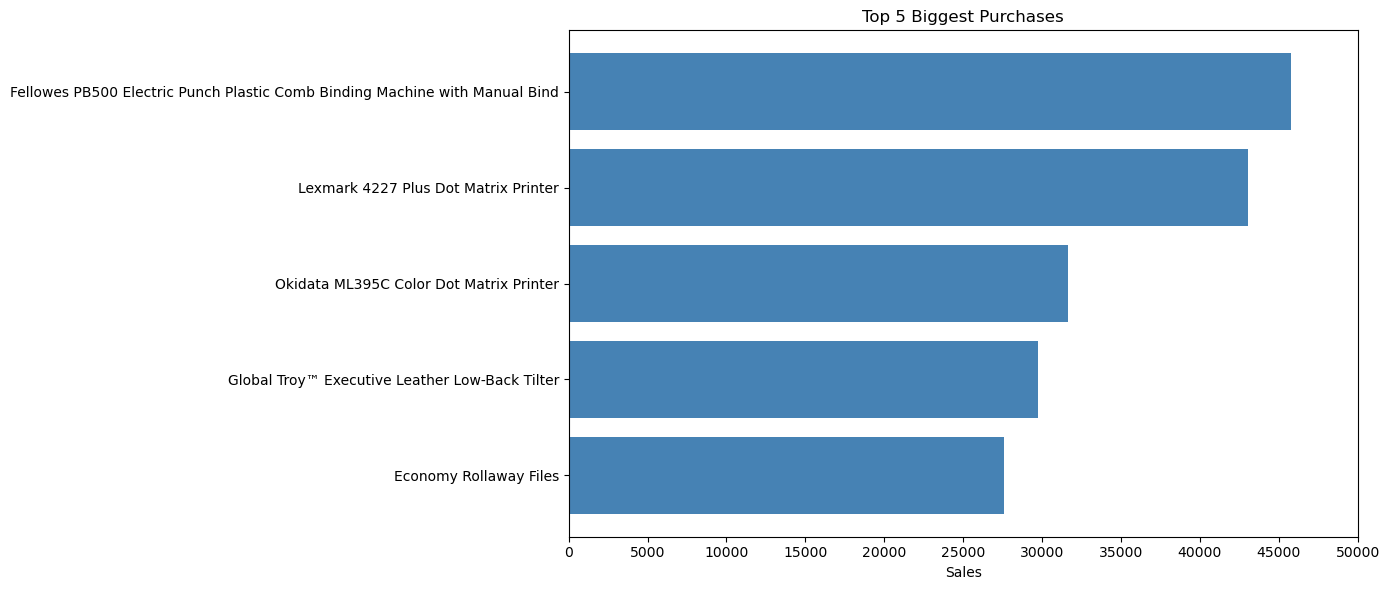

In [653]:
top5 = df.sort_values("Sales", ascending=False).head(5)

plt.figure(figsize=(14,6))
bars = plt.barh(top5["Product Name"], top5["Sales"], color="steelblue")

plt.title("Top 5 Biggest Purchases")
plt.xlabel("Sales")

plt.gca().invert_yaxis()  

max_sales = top5["Sales"].max()
step = 5000
plt.xticks(range(0, int(max_sales + step), step))

plt.tight_layout()
plt.show()


This graphic shows "Profit" and "Sales" by the manager and compare the results. On this graphic we can see max sales and profit values and min sales and profit values per "Manager" too. Black line on the graphic is 0.

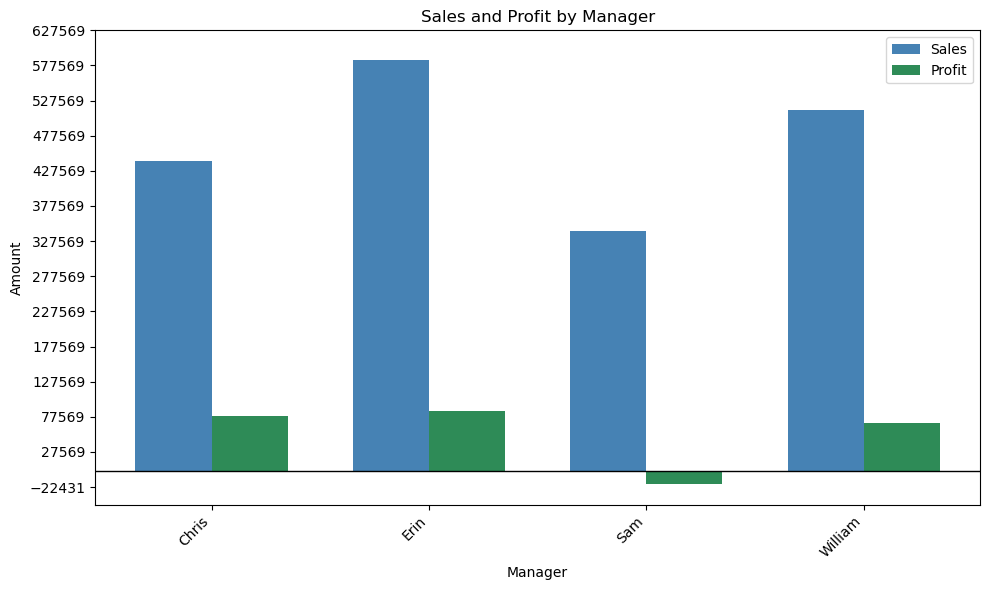

In [654]:
grouped = df1.groupby("Manager")[["Sales", "Profit"]].sum().reset_index()

managers = grouped["Manager"]
sales = grouped["Sales"]
profit = grouped["Profit"]

x = np.arange(len(managers))  
width = 0.35 

fig, ax = plt.subplots(figsize=(10,6))

bars1 = ax.bar(x - width/2, sales, width, label="Sales", color="steelblue")
bars2 = ax.bar(x + width/2, profit, width, label="Profit", color="seagreen")

ax.set_xlabel("Manager")
ax.set_ylabel("Amount")
ax.set_title("Sales and Profit by Manager")
ax.set_xticks(x)
ax.set_xticklabels(managers, rotation=45, ha="right")
ax.legend()


max_val = max(sales.max(), profit.max())
min_val = min(sales.min(), profit.min())


yticks_start = min(0, min_val - 5000) 
yticks_end = max_val + 50000
ax.set_yticks(np.arange(yticks_start, yticks_end, 50000))

#Black line is 0
ax.axhline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()